# Customer Segmentation Analysis

## Objective

The objective of this project is to apply clustering techniques to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel(r"C:\Users\Admin\Downloads\Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [10]:
print("Unique Invoices:", df['InvoiceNo'].nunique())
print("Unique Products:", df['StockCode'].nunique())
print("Unique Customers:", df['CustomerID'].nunique())
print("Countries:", df['Country'].nunique())

Unique Invoices: 25900
Unique Products: 4070
Unique Customers: 4372
Countries: 38


In [11]:
#Investigate the negative transactions

df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

In [12]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [13]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

In [14]:
#Check how many CustomerIDs are missing
missing_customer = df['CustomerID'].isnull().sum()

missing_percentage = (missing_customer / len(df)) * 100

print("Missing CustomerID:", missing_customer)
print("Missing CustomerID (%):", round(missing_percentage, 2))

Missing CustomerID: 135080
Missing CustomerID (%): 24.93


In [15]:
print("Rows before removing duplicates:", len(df))

df_clean = df.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Rows before removing duplicates: 541909
Rows after removing duplicates: 536641


In [16]:
# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove cancelled invoices
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove zero or negative unit prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print("Rows after cleaning:", len(df_clean))
print("Missing CustomerID:", df_clean['CustomerID'].isnull().sum())
print("Negative Quantity:", (df_clean['Quantity'] < 0).sum())
print("Invalid UnitPrice:", (df_clean['UnitPrice'] <= 0).sum())

Rows after cleaning: 392692
Missing CustomerID: 0
Negative Quantity: 0
Invalid UnitPrice: 0


In [17]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
df_clean.shape

(392692, 9)

In [19]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [20]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [21]:
df_clean.loc[df_clean['Quantity'].idxmax()]

InvoiceNo                           581483
StockCode                            23843
Description    PAPER CRAFT , LITTLE BIRDIE
Quantity                             80995
InvoiceDate            2011-12-09 09:15:00
UnitPrice                             2.08
CustomerID                         16446.0
Country                     United Kingdom
TotalAmount                       168469.6
Name: 540421, dtype: object

In [22]:
df_clean.loc[df_clean['TotalAmount'].idxmax()]

InvoiceNo                           581483
StockCode                            23843
Description    PAPER CRAFT , LITTLE BIRDIE
Quantity                             80995
InvoiceDate            2011-12-09 09:15:00
UnitPrice                             2.08
CustomerID                         16446.0
Country                     United Kingdom
TotalAmount                       168469.6
Name: 540421, dtype: object

In [23]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Last transaction date:", df_clean['InvoiceDate'].max())
print("Reference date:", snapshot_date)

Last transaction date: 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00


In [24]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [25]:
rfm.shape

(4338, 3)

In [26]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [27]:
rfm['AveragePurchaseValue'] = rfm['Monetary'] / rfm['Frequency']

rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue
CustomerID,,,,
12346.0,326,1,77183.60,77183.600000
12347.0,2,7,4310.00,615.714286
12348.0,75,4,1797.24,449.310000
12349.0,19,1,1757.55,1757.550000
12350.0,310,1,334.40,334.400000


In [28]:
rfm['AveragePurchaseValue'].describe()

count     4338.000000
mean       417.645735
std       1796.511343
min          3.450000
25%        177.867083
50%        291.940000
75%        428.280625
max      84236.250000
Name: AveragePurchaseValue, dtype: float64

In [29]:
customer_lifespan = df_clean.groupby('CustomerID')['InvoiceDate'].agg(
    FirstPurchase='min',
    LastPurchase='max'
)

customer_lifespan['LifespanDays'] = (
    customer_lifespan['LastPurchase'] -
    customer_lifespan['FirstPurchase']
).dt.days

customer_lifespan.head()

,FirstPurchase,LastPurchase,LifespanDays
CustomerID,,,
12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,0
12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,365
12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,282
12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,0
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,0


In [30]:
rfm = rfm.join(customer_lifespan['LifespanDays'])

In [31]:
rfm['LifespanYears'] = rfm['LifespanDays'] / 365

rfm['CLV'] = (
    rfm['AveragePurchaseValue'] *
    rfm['Frequency'] *
    rfm['LifespanYears']
)

rfm[['Recency', 'Frequency', 'Monetary',
     'AveragePurchaseValue', 'LifespanDays', 'CLV']].head()

,Recency,Frequency,Monetary,AveragePurchaseValue,LifespanDays,CLV
CustomerID,,,,,,
12346.0,326,1,77183.60,77183.600000,0,0.000000
12347.0,2,7,4310.00,615.714286,365,4310.000000
12348.0,75,4,1797.24,449.310000,282,1388.552548
12349.0,19,1,1757.55,1757.550000,0,0.000000
12350.0,310,1,334.40,334.400000,0,0.000000


In [32]:
rfm[['Recency', 'Frequency', 'Monetary',
     'AveragePurchaseValue', 'LifespanDays', 'CLV']].describe()

,Recency,Frequency,Monetary,AveragePurchaseValue,LifespanDays,CLV
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081,417.645735,130.448594,1464.580579
std,100.014169,7.697998,8985.230220,1796.511343,132.039554,8395.833403
min,1.000000,1.000000,3.750000,3.450000,0.000000,0.000000
25%,18.000000,1.000000,306.482500,177.867083,0.000000,0.000000
50%,51.000000,2.000000,668.570000,291.940000,92.500000,162.190192
75%,142.000000,5.000000,1660.597500,428.280625,251.750000,935.592712
max,374.000000,209.000000,280206.020000,84236.250000,373.000000,270993.767288


In [33]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

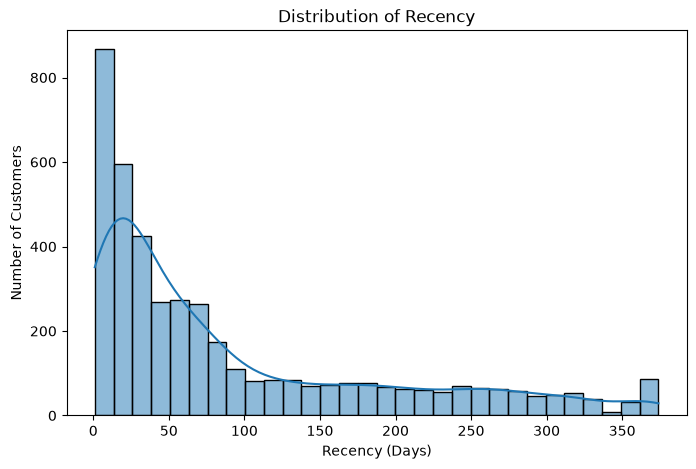

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.show()

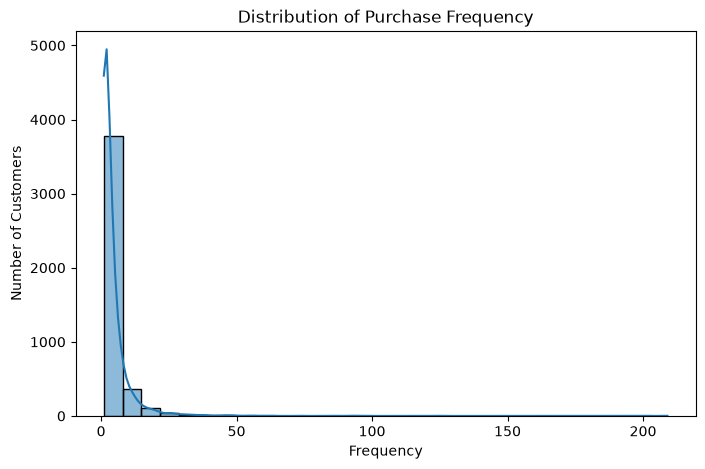

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Distribution of Purchase Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.show()

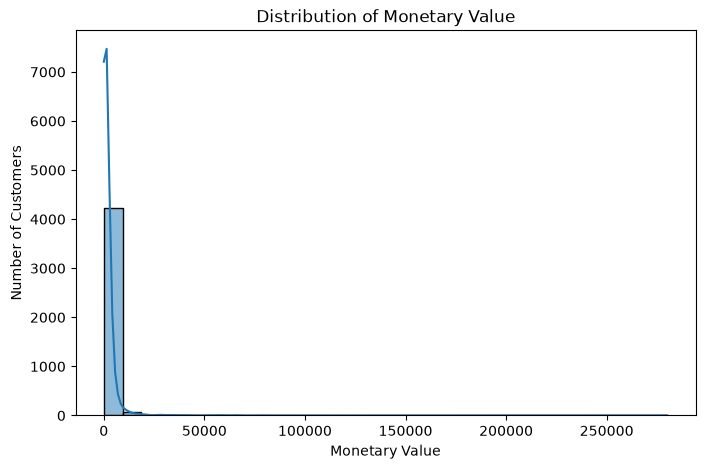

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Distribution of Monetary Value')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')
plt.show()

### Observations

- Recency values show variation in how recently customers made their purchases.
- Purchase Frequency is concentrated among customers with relatively few transactions, while a smaller group of customers purchases much more frequently.
- Monetary value is strongly right-skewed, with a small number of customers contributing substantially higher spending.
- Due to the skewness in the RFM variables, a log transformation is applied before standardisation and clustering.

In [37]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log = np.log1p(rfm_log)

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [38]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.707716
12347.0,-2.038734,1.074425,1.414903
12348.0,0.373104,0.386304,0.720024
12349.0,-0.623086,-0.955214,0.702287
12350.0,1.424558,-0.955214,-0.614514


In [40]:
#elbow method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

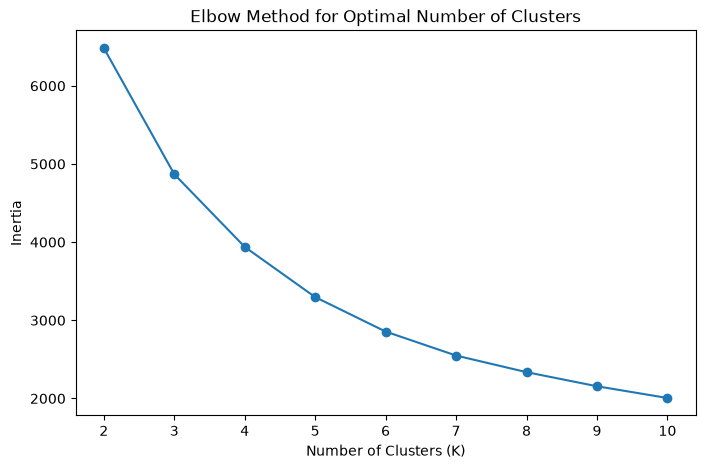

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))

plt.show()

In [42]:
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 6483.59
K = 3: Inertia = 4869.49
K = 4: Inertia = 3939.05
K = 5: Inertia = 3296.71
K = 6: Inertia = 2855.76
K = 7: Inertia = 2548.82
K = 8: Inertia = 2336.34
K = 9: Inertia = 2156.01
K = 10: Inertia = 2005.75


### Observation

The inertia decreases as the number of clusters increases, with the rate of
improvement becoming more gradual after the initial reduction. Based on the
Elbow Method, K=4 was selected as a practical cluster solution for customer
segmentation.

In [45]:
#Apply K-Means with 4 Clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,LifespanDays,LifespanYears,CLV,Cluster
CustomerID,,,,,,,,
12346.0,326,1,77183.60,77183.600000,0,0.000000,0.000000,3
12347.0,2,7,4310.00,615.714286,365,1.000000,4310.000000,0
12348.0,75,4,1797.24,449.310000,282,0.772603,1388.552548,3
12349.0,19,1,1757.55,1757.550000,0,0.000000,0.000000,2
12350.0,310,1,334.40,334.400000,0,0.000000,0.000000,1


In [46]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

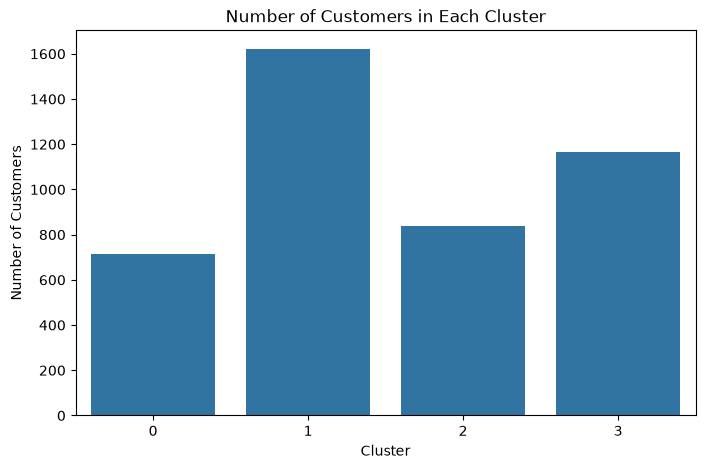

In [47]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x='Cluster',
    order=sorted(rfm['Cluster'].unique())
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

### Observation

The customer base is divided into four clusters based on Recency, Frequency, and Monetary purchasing behaviour. The number of customers varies across the clusters, indicating that the identified customer segments are not equally distributed.

In [48]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'AveragePurchaseValue': 'mean',
    'LifespanDays': 'mean',
    'CLV': 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary,AveragePurchaseValue,LifespanDays,CLV
Cluster,,,,,,
0,12.17,13.75,8088.02,623.81,298.40,7174.76
1,181.51,1.32,341.00,282.45,25.85,29.56
2,17.70,2.19,557.32,278.28,107.75,195.46
3,71.64,4.08,1801.78,579.69,189.54,880.10


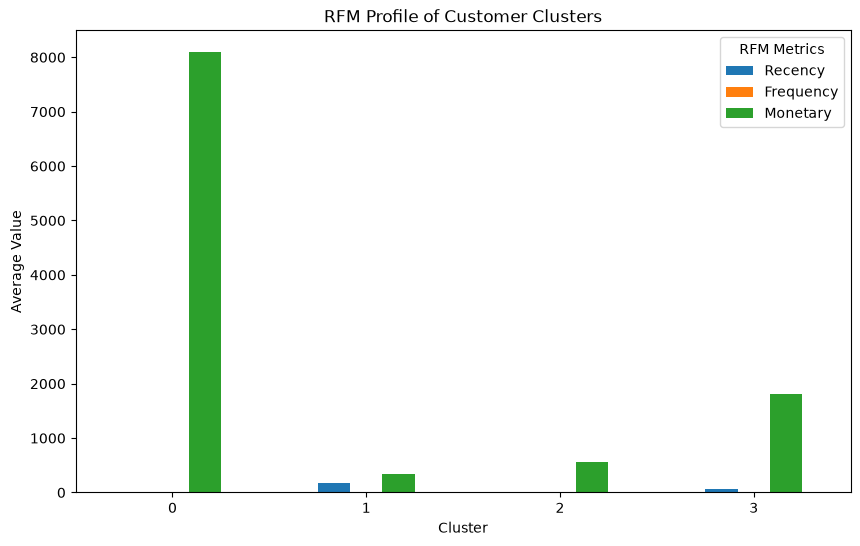

In [49]:
cluster_profile[['Recency', 'Frequency', 'Monetary']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('RFM Profile of Customer Clusters')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='RFM Metrics')
plt.show()

In [50]:
cluster_names = {
    0: 'Champions / High-Value Loyal Customers',
    1: 'At-Risk / Inactive Low-Value Customers',
    2: 'Recent / Potential Customers',
    3: 'Loyal / Regular Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm[['Recency', 'Frequency', 'Monetary', 'CLV',
     'Cluster', 'Segment']].head()

,Recency,Frequency,Monetary,CLV,Cluster,Segment
CustomerID,,,,,,
12346.0,326,1,77183.60,0.000000,3,Loyal / Regular Customers
12347.0,2,7,4310.00,4310.000000,0,Champions / High-Value Loyal Customers
12348.0,75,4,1797.24,1388.552548,3,Loyal / Regular Customers
12349.0,19,1,1757.55,0.000000,2,Recent / Potential Customers
12350.0,310,1,334.40,0.000000,1,At-Risk / Inactive Low-Value Customers


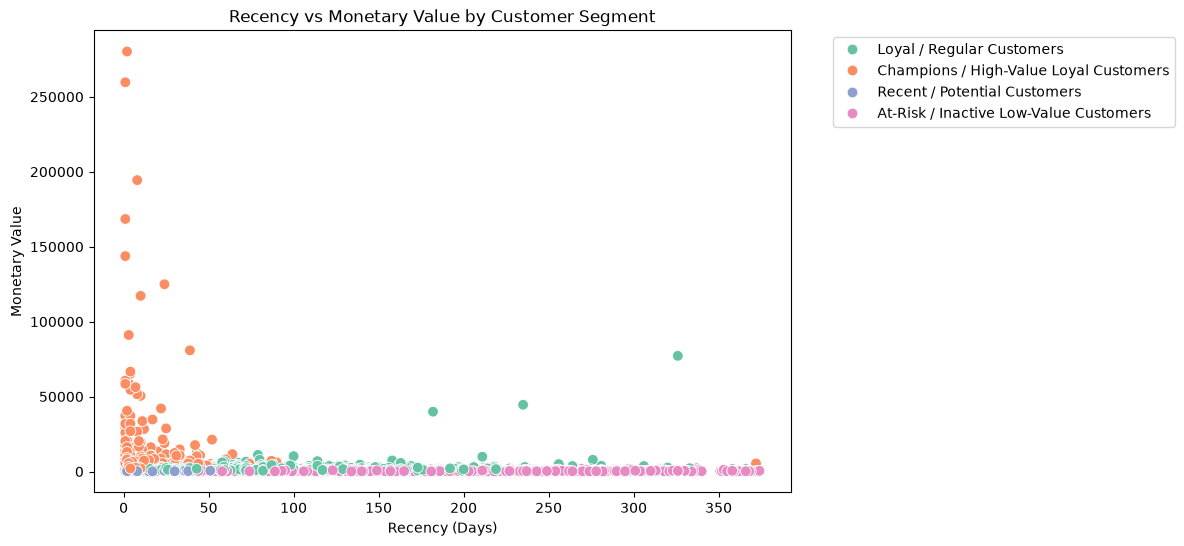

In [51]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='Set2',
    s=60
)

plt.title('Recency vs Monetary Value by Customer Segment')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Observation

The scatter plot shows differences in customer purchasing behaviour across the identified segments. High-value customers generally have lower recency and higher monetary values, while the at-risk segment contains customers with higher recency and lower spending.

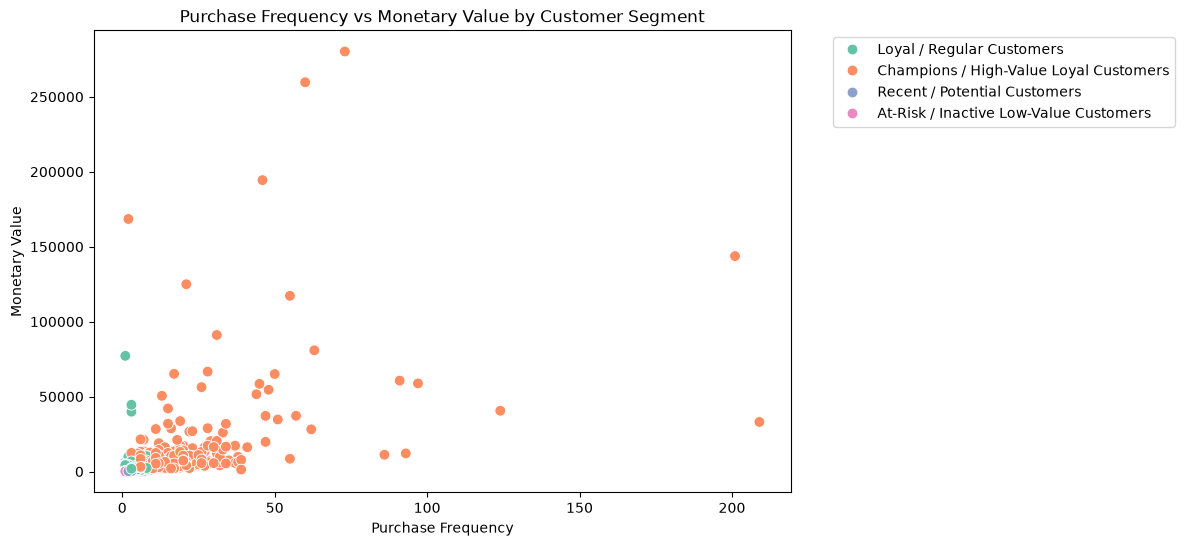

In [52]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='Set2',
    s=60
)

plt.title('Purchase Frequency vs Monetary Value by Customer Segment')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Observation

The Frequency vs Monetary scatter plot shows that the high-value customer segment combines frequent purchasing with substantially higher spending. Customers in the at-risk segment have both low purchase frequency and low monetary value, while the regular customer segment occupies an intermediate position.

In [53]:
segment_order = [
    'Champions / High-Value Loyal Customers',
    'Loyal / Regular Customers',
    'Recent / Potential Customers',
    'At-Risk / Inactive Low-Value Customers'
]

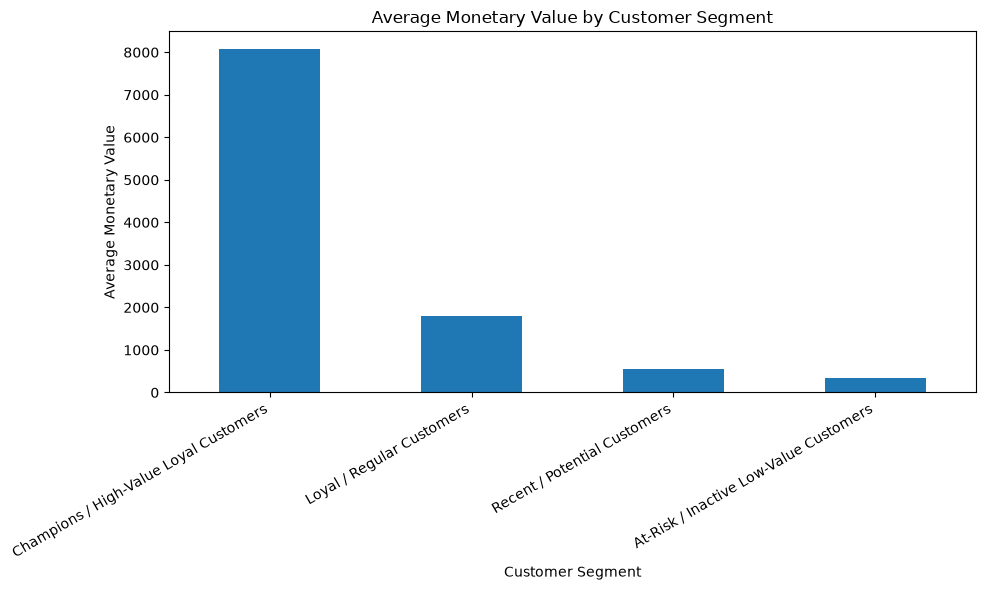

In [54]:
segment_monetary = rfm.groupby('Segment')['Monetary'].mean().reindex(segment_order)

plt.figure(figsize=(10, 6))

segment_monetary.plot(kind='bar')

plt.title('Average Monetary Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

### Observation

Champions / High-Value Loyal Customers have the highest average monetary value by a large margin. Loyal / Regular Customers form the next most valuable segment, while Recent / Potential Customers and At-Risk / Inactive Low-Value Customers have substantially lower average spending.

In [55]:
segment_summary = rfm.groupby('Segment').agg(
    CustomerCount=('Segment', 'size'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    AvgPurchaseValue=('AveragePurchaseValue', 'mean'),
    AvgCLV=('CLV', 'mean')
).reindex(segment_order).round(2)

segment_summary

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,AvgPurchaseValue,AvgCLV
Segment,,,,,,
Champions / High-Value Loyal Customers,713,12.17,13.75,8088.02,623.81,7174.76
Loyal / Regular Customers,1166,71.64,4.08,1801.78,579.69,880.10
Recent / Potential Customers,837,17.70,2.19,557.32,278.28,195.46
At-Risk / Inactive Low-Value Customers,1622,181.51,1.32,341.00,282.45,29.56


## Customer Segment Summary

The customer segmentation analysis identified four distinct groups based on purchasing behaviour. The segments differ in purchase recency, purchase frequency, spending level, and estimated customer lifetime value.

The Champions / High-Value Loyal Customers represent the most valuable group because they purchase frequently, purchased recently, and generate substantially higher monetary value.

The At-Risk / Inactive Low-Value Customers show the weakest purchasing behaviour, with high recency, low frequency, and low monetary contribution.

The Recent / Potential Customers have purchased recently but have relatively low purchase frequency and spending, making them a potential growth segment.

The Loyal / Regular Customers demonstrate consistent purchasing behaviour and represent an important segment that can potentially be developed into high-value customers.

# Business Recommendations

Based on the RFM analysis and K-Means customer segmentation, the following marketing strategies are recommended:

### 1. Reward Champions / High-Value Loyal Customers

Champions have the lowest recency, highest purchase frequency, highest monetary value, and highest estimated CLV.

**Recommendation:**
- Introduce VIP or loyalty programs.
- Provide exclusive offers and early access to new products.
- Recommend premium and complementary products.
- Focus on retention because losing these customers could have a significant revenue impact.

### 2. Re-engage At-Risk / Inactive Low-Value Customers

This segment has the highest recency and the lowest purchase frequency, monetary value, and CLV.

**Recommendation:**
- Launch targeted win-back campaigns.
- Provide limited-time personalized discounts.
- Send reminders based on previous purchases.
- Test low-cost reactivation campaigns before allocating large marketing budgets.

### 3. Develop Recent / Potential Customers

These customers have purchased recently but have relatively low purchase frequency and monetary value.

**Recommendation:**
- Encourage repeat purchases through follow-up offers.
- Use cross-selling and product recommendations.
- Provide incentives for the next purchase.
- Introduce product bundles to increase transaction value.

### 4. Strengthen Loyal / Regular Customers

These customers show moderate recency and relatively high purchase frequency and spending.

**Recommendation:**
- Strengthen loyalty through rewards and personalized promotions.
- Recommend products based on previous purchases.
- Use bundle offers to increase spending.
- Encourage these customers to move toward the Champions segment.

### 5. Use Segment-Specific Marketing

A single marketing strategy should not be applied to every customer.

The business should use the identified segments to allocate marketing resources according to customer value and purchasing behaviour. High-value customers should receive retention-focused strategies, while inactive customers should receive targeted reactivation campaigns.

# Conclusion

This project performed customer segmentation using RFM analysis and K-Means clustering on the Online Retail dataset.

After data cleaning, 4,338 customers were analysed using Recency, Frequency, and Monetary behavioural features. The RFM variables were log-transformed to reduce the effect of extreme values and standardized before clustering.

The Elbow Method indicated that four clusters provided a suitable segmentation of the customer base. The resulting clusters revealed four distinct customer groups: Champions / High-Value Loyal Customers, At-Risk / Inactive Low-Value Customers, Recent / Potential Customers, and Loyal / Regular Customers.

The segmentation provides actionable insights into customer purchasing behaviour. The business can use these segments to improve customer retention, personalize marketing campaigns, encourage repeat purchases, re-engage inactive customers, and focus resources on high-value customers.

Overall, the analysis demonstrates how RFM analysis and unsupervised machine learning can transform transaction-level data into meaningful customer segments and support data-driven marketing decisions.

## Key Insights

- **Champions / High-Value Loyal Customers** are the most valuable segment, with the highest purchase frequency, monetary value, and estimated CLV.
- **At-Risk / Inactive Low-Value Customers** require re-engagement because they show the highest recency and lowest purchasing activity.
- **Recent / Potential Customers** represent an opportunity for growth because they have purchased recently but have relatively low frequency and spending.
- **Loyal / Regular Customers** provide a stable customer base and can potentially be developed into higher-value customers.
- Customer spending is highly right-skewed, demonstrating that a relatively small group of customers contributes substantially higher revenue.
- Segment-specific marketing can help the business allocate promotional and retention efforts more effectively.